In [1]:
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm
import random
import os

In [2]:
data_home = "."
input_dir = "."
data_dir = "."

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

In [3]:
treatment_groups = ["PBMC_Control1", "PBMC_Control2", "Lung_Cancer_PBMC"]
adata_dict = {}
for group in treatment_groups:
    sample_adata = ad.read_h5ad(os.path.join(input_dir, group + ".h5ad"))
    sample_adata.var_names_make_unique()
    adata_dict[group] = sample_adata
adata = ad.concat(adata_dict, label="sample")
adata.obs_names_make_unique()
display(adata.obs["sample"].value_counts())
del adata_dict

print(adata)

sample
PBMC_Control1       20490
PBMC_Control2       18232
Lung_Cancer_PBMC    15725
Name: count, dtype: int64

AnnData object with n_obs × n_vars = 54447 × 18129
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample'


## QC / Filtering

In [4]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars="mt", inplace=True, log1p=True
)

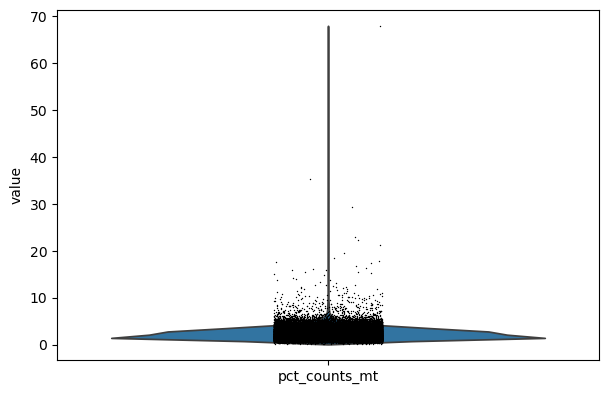

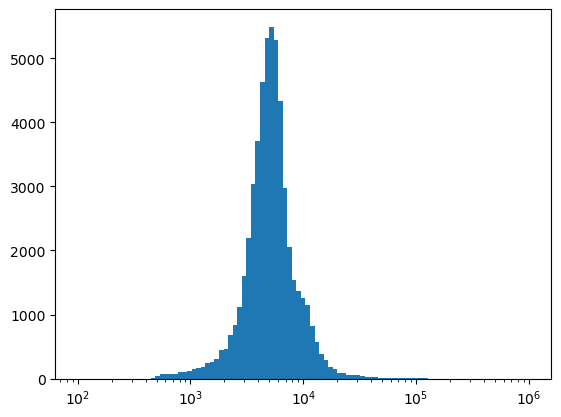

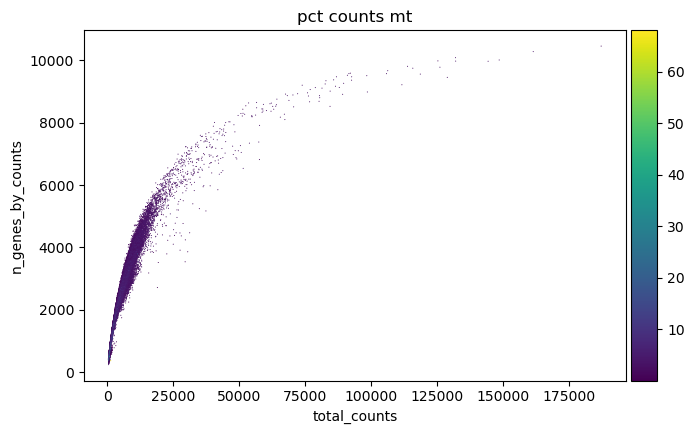

In [5]:
sc.pl.violin(adata, "pct_counts_mt")
plt.hist(adata.obs["total_counts"], bins = 10 ** np.linspace(2, 6, 100))
plt.xscale("log")
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [6]:
display(adata.obs["sample"].value_counts())
display(adata)

print("Doublet removal:")
adata = adata[adata.obs['scDblFinder.class'] == "singlet", :]
display(adata.obs["sample"].value_counts())
display(adata)

print("Read counts filtering for cells:")
sc.pp.filter_cells(adata, min_counts=200) # remove cells with less than 200 total counts
sc.pp.filter_cells(adata, max_counts=20_000) # remove cells with more than 20,000 total counts
display(adata.obs["sample"].value_counts())
display(adata)

print("Min cells filtering for genes:")
# sc.pp.filter_cells(adata, min_genes=100) # remove cells with less than 100 genes
sc.pp.filter_genes(adata, min_cells=3) # remove genes found in less than 3 cells
display(adata.obs["sample"].value_counts())
display(adata)

print("Max mt percent filtering:")
adata = adata[adata.obs['pct_counts_mt'] < 5, :] # remove cells with over 5% mitochondrial reads
display(adata.obs["sample"].value_counts())
display(adata)

sample
PBMC_Control1       20490
PBMC_Control2       18232
Lung_Cancer_PBMC    15725
Name: count, dtype: int64

AnnData object with n_obs × n_vars = 54447 × 18129
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

Doublet removal:


sample
PBMC_Control1       18295
PBMC_Control2       16178
Lung_Cancer_PBMC    14422
Name: count, dtype: int64

View of AnnData object with n_obs × n_vars = 48895 × 18129
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

...

sample
PBMC_Control1       18210
PBMC_Control2       16165
Lung_Cancer_PBMC    14412
Name: count, dtype: int64

AnnData object with n_obs × n_vars = 48787 × 15645
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

Max mt percent filtering:


sample
PBMC_Control1       18099
PBMC_Control2       15435
Lung_Cancer_PBMC    14030
Name: count, dtype: int64

View of AnnData object with n_obs × n_vars = 47564 × 15645
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

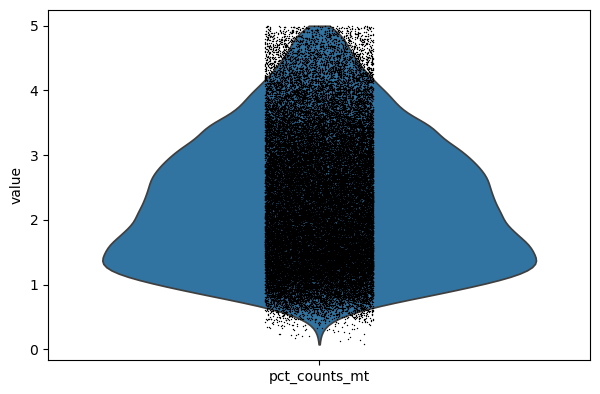

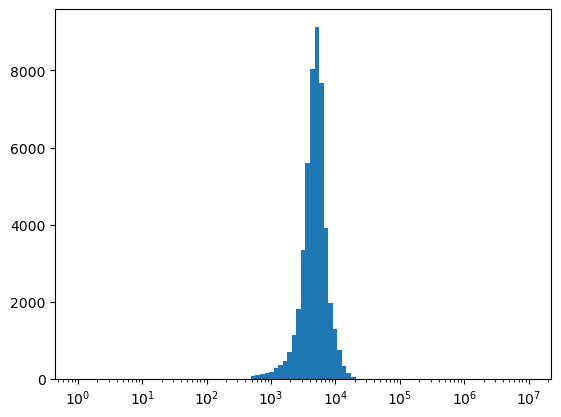

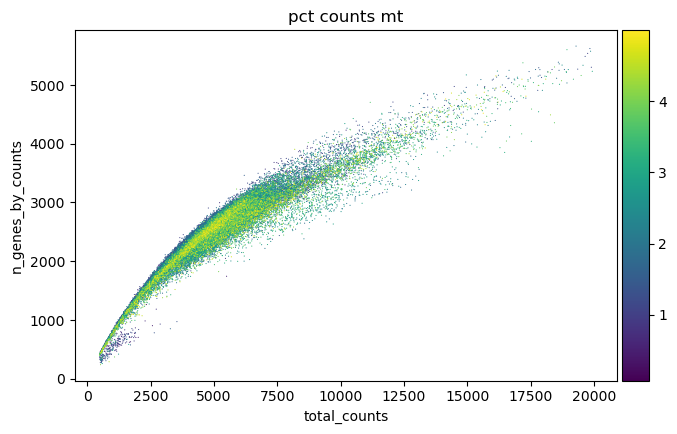

In [7]:
sc.pl.violin(adata, "pct_counts_mt")
plt.hist(adata.obs["total_counts"], bins = 10 ** np.linspace(0, 7, 100))
plt.xscale("log")
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Normalization

/var/folders/2s/_00dd2vx0blcvkt9x4m4l1th0000gn/T/ipykernel_8989/3604015059.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


(array([1.000e+00, 2.000e+00, 2.000e+00, 2.000e+00, 2.000e+00, 5.000e+00,
        4.000e+00, 6.000e+00, 7.000e+00, 6.000e+00, 6.000e+00, 1.100e+01,
        7.000e+00, 2.000e+00, 1.000e+01, 9.000e+00, 9.000e+00, 1.900e+01,
        1.700e+01, 2.700e+01, 2.300e+01, 1.700e+01, 2.800e+01, 3.500e+01,
        2.400e+01, 2.500e+01, 3.400e+01, 2.200e+01, 3.100e+01, 2.800e+01,
        2.500e+01, 2.600e+01, 3.100e+01, 3.700e+01, 3.200e+01, 3.100e+01,
        2.700e+01, 3.200e+01, 3.100e+01, 3.800e+01, 4.800e+01, 4.100e+01,
        4.100e+01, 6.600e+01, 5.400e+01, 7.900e+01, 6.000e+01, 6.600e+01,
        9.100e+01, 1.040e+02, 8.600e+01, 1.070e+02, 1.210e+02, 1.200e+02,
        1.460e+02, 1.410e+02, 1.650e+02, 2.070e+02, 2.180e+02, 2.190e+02,
        3.090e+02, 3.660e+02, 4.370e+02, 4.790e+02, 5.750e+02, 6.880e+02,
        8.180e+02, 9.740e+02, 1.163e+03, 1.433e+03, 1.527e+03, 1.817e+03,
        2.079e+03, 2.271e+03, 2.553e+03, 2.841e+03, 3.115e+03, 3.281e+03,
        3.283e+03, 3.087e+03, 2.767e+0

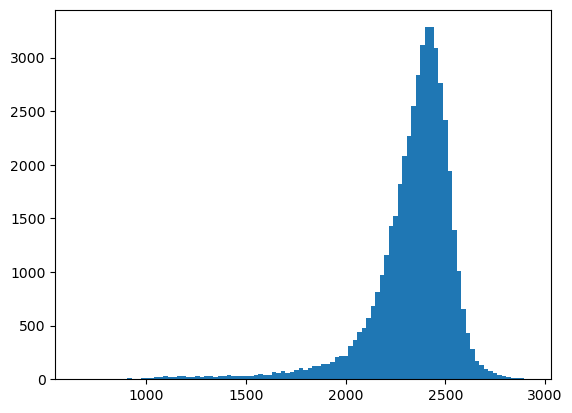

In [8]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata
plt.hist(adata.raw.X.sum(1), bins=100)

## PCA

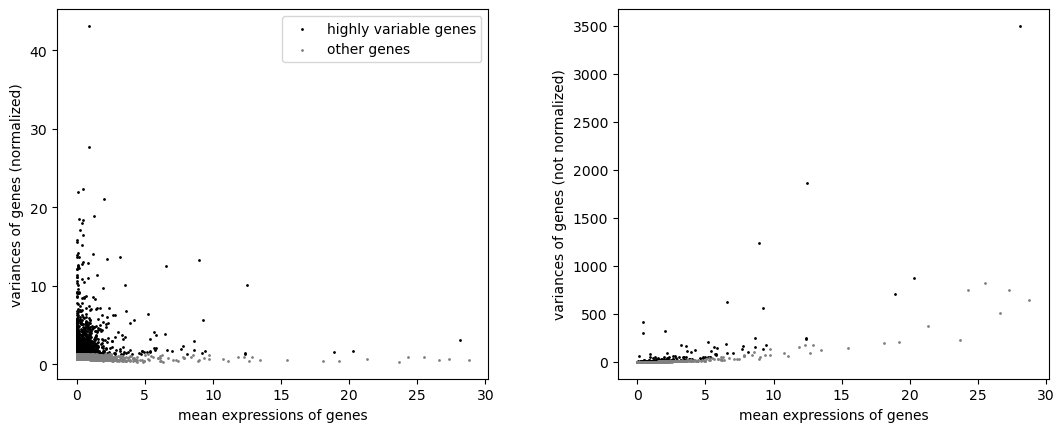

In [9]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000, layer="counts")
sc.pl.highly_variable_genes(adata)

/var/folders/2s/_00dd2vx0blcvkt9x4m4l1th0000gn/T/ipykernel_8989/2304979999.py:1: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, svd_solver="arpack", random_state=SEED, use_highly_variable=True)


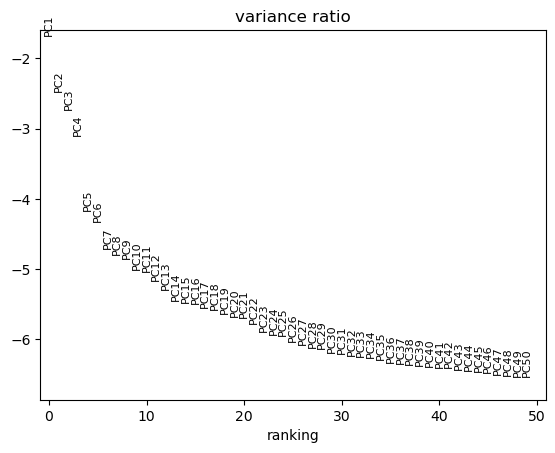

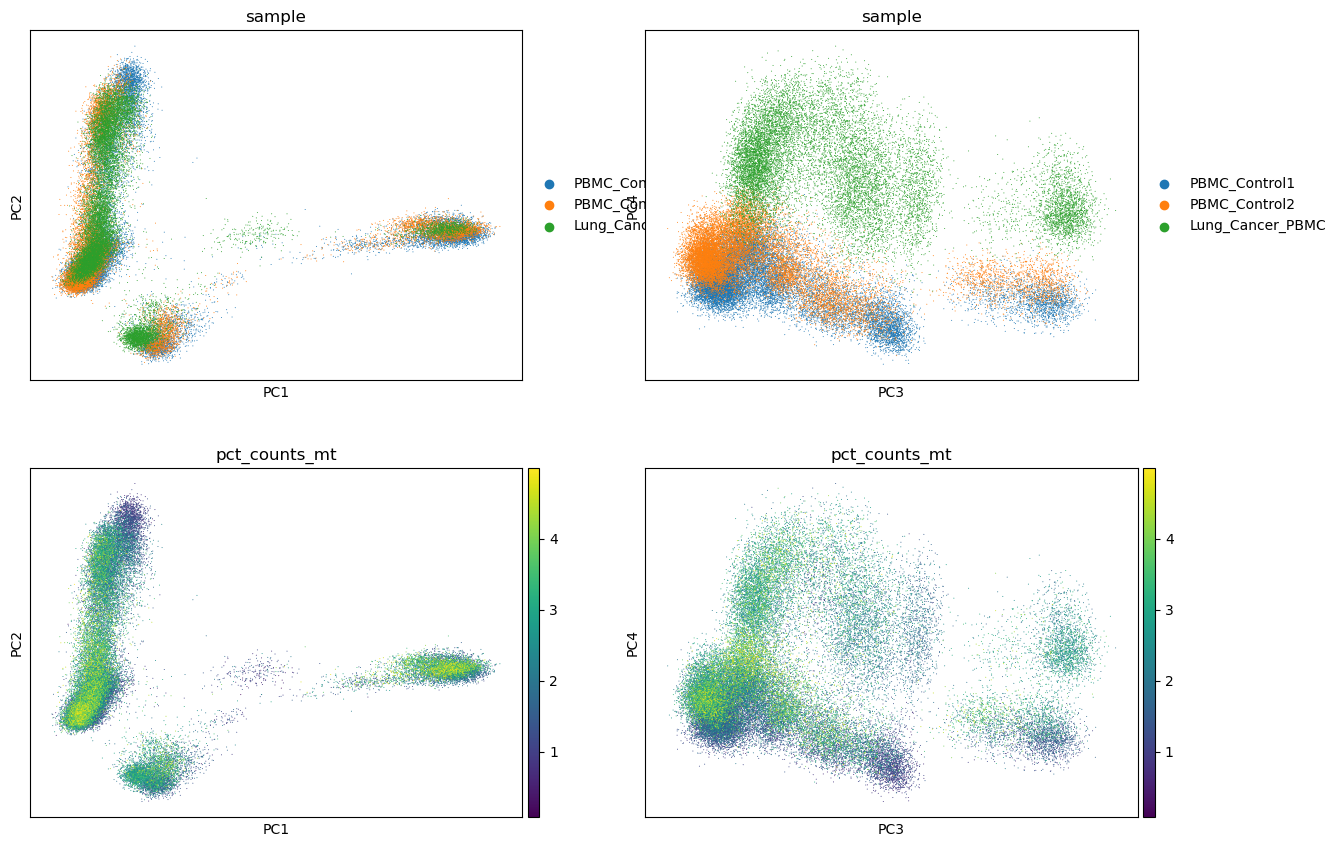

In [10]:
sc.tl.pca(adata, svd_solver="arpack", random_state=SEED, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

## Example UMAP w/o Harmony

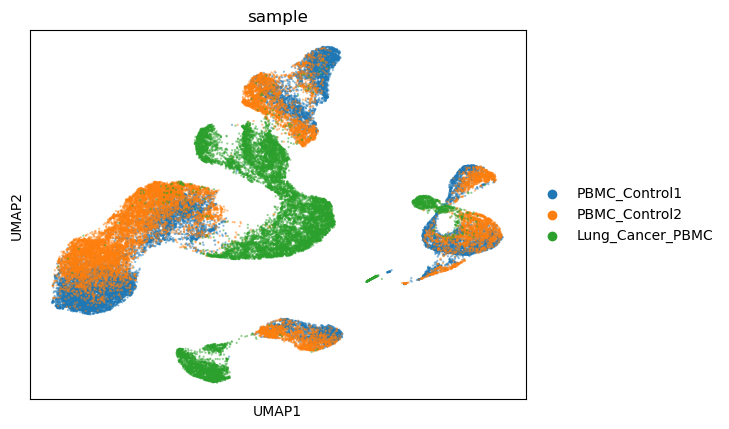

In [11]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=6, use_rep="X_pca",
                method='umap', metric='euclidean', random_state=SEED)
sc.tl.umap(adata, min_dist=0.2, spread=1.0, random_state=SEED)
sc.pl.umap(adata, color="sample", alpha=0.5, s=10)

## Batch Correction w/ Harmony

In [12]:
pca = adata.obsm["X_pca"].astype(np.float64)
harmony_out = hm.run_harmony(pca, adata.obs, "sample")
adata.obsm["X_pca_harmony"] = harmony_out.Z_corr


2026-04-10 12:54:02,840 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-04-10 12:54:02,841 - harmonypy - INFO -   Parameters:
2026-04-10 12:54:02,841 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-10 12:54:02,841 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-10 12:54:02,842 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-10 12:54:02,842 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-10 12:54:02,843 - harmonypy - INFO -     nclust: 100
2026-04-10 12:54:02,843 - harmonypy - INFO -     block_size: 0.05
2026-04-10 12:54:02,843 - harmonypy - INFO -     lamb: [1. 1. 1.]
2026-04-10 12:54:02,844 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-04-10 12:54:02,845 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-10 12:54:02,845 - harmonypy - INFO -     verbose: True
2026-04-10 12:54:02,845 - harmonypy - INFO -     random_state: 0
2026-04-10 12:54:02,846 - harmonypy - INFO -   Data: 50 PCs × 47564 cells
2026-04-10 12:54:02,846 - harmonypy 

## Neighbors and UMAP

In [13]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=6, use_rep="X_pca_harmony",
                method='umap', metric='euclidean', random_state=SEED)

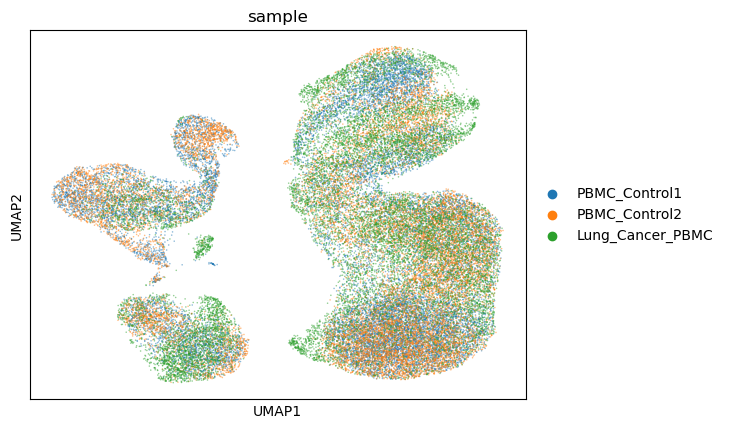

In [14]:
sc.tl.umap(adata, random_state=SEED)
sc.pl.umap(adata, color="sample", alpha=0.5, s=5)

In [15]:
adata.write(os.path.join(data_dir, "pp_and_umap_data.h5ad"))